# Vampire Survivors Weapon Screen Recorder

This notebook detects and records the **weapon icons in the first HUD row at the top-left of gameplay**. It uses the [Vampire Survivors Wiki weapon page](https://vampire-survivors.fandom.com/wiki/Weapons) and its [weapon-icon catalogue](https://vampire-survivors.fandom.com/wiki/Category:Weapon_icons) as the reference library.

The workflow produces:

- a wide CSV with one row per sampled video time and columns `weapon_1` through `weapon_6`;
- a compact event CSV for acquisitions, replacements, and evolutions;
- confidence scores and `needs_review` flags;
- annotated debug frames for visual quality control; and
- raw per-frame guesses alongside stabilized results, so no automated correction is hidden.

## What Counts as a Weapon Here?

The game HUD has six weapon slots in its **first row**. Passive items occupy the row below and are deliberately excluded. Empty weapon cells are translucent, so enemies and effects can sometimes show through them. The detector handles that by checking several nearby frames and accepting new slot contents only when the same identity persists.

The detector is deliberately scoped to the top-left weapon row so passive-item slots are not included in the output.

In [1]:
from pathlib import Path
import importlib.util
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

Matplotlib is building the font cache; this may take a moment.


## Project Paths

This cell finds `MNL/03_weapons` whether the notebook is opened from the repository root or from this `notebooks` folder.

In [ ]:
def find_weapons_dir():
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "03_weapons",
        cwd / "MNL" / "03_weapons",
        cwd,
        cwd.parent,
        cwd.parent.parent / "03_weapons",
    ]
    for candidate in candidates:
        if (candidate / "scripts" / "weapon_screen_recorder.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find the MNL/03_weapons workspace.")


WEAPONS_DIR = find_weapons_dir()
MNL_DIR = WEAPONS_DIR.parent
VIDEO_DIR = MNL_DIR / "00-Videos"
ICON_DIR = WEAPONS_DIR / "templates" / "wiki_icons"
MANIFEST_PATH = WEAPONS_DIR / "data" / "wiki_weapon_manifest.csv"
SCRIPT_PATH = WEAPONS_DIR / "scripts" / "weapon_screen_recorder.py"
RESULTS_DIR = WEAPONS_DIR / "results"

print("Weapons workspace:", WEAPONS_DIR)
print("Video folder:", VIDEO_DIR)
print("Wiki icon folder:", ICON_DIR)
print("Manifest:", MANIFEST_PATH)

## Load the Reusable Detector

The notebook explains and operates the pipeline; the reusable implementation lives in `scripts/weapon_screen_recorder.py` so a full video can also be processed from the terminal.

In [3]:
spec = importlib.util.spec_from_file_location("weapon_screen_recorder", SCRIPT_PATH)
detector = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = detector
spec.loader.exec_module(detector)

config = detector.MatchConfig()
config

MatchConfig(template_inner_margin=0.18, template_background_distance=32.0, color_histogram_weight=0.22, search_padding_fraction=0.055, occupied_luma_std=24.0, occupied_saturation_std=28.0, occupied_laplacian_var=800.0, high_score=0.6, high_margin=0.07, medium_score=0.48, medium_margin=0.025, unknown_score=0.38)

## Wiki Weapon Catalogue

The local folder contains the complete set returned by the wiki's `Weapon icons` category at download time. The manifest keeps each weapon name, local filename, and original wiki image URL.

Set `REFRESH_WIKI_CATALOGUE = True` only when internet access is available and you intentionally want to update the local reference set. Existing icons are kept unless `force=True` is passed.

In [4]:
REFRESH_WIKI_CATALOGUE = False

if REFRESH_WIKI_CATALOGUE:
    manifest = detector.download_wiki_weapon_icons(
        ICON_DIR, MANIFEST_PATH, force=False
    )
else:
    manifest = detector.load_weapon_manifest(MANIFEST_PATH)

downloaded_files = sorted(ICON_DIR.glob("*.png"))
print(f"Manifest rows: {len(manifest)}")
print(f"Downloaded PNG icons: {len(downloaded_files)}")
display(manifest.head(10))

Manifest rows: 121
Downloaded PNG icons: 121


,weapon_name,filename,wiki_image_url
0,108 Bocce,108_Bocce.png,https://static.wikia.nocookie.net/vampire-surv...
1,Anima of Mortaccio,Anima_of_Mortaccio.png,https://static.wikia.nocookie.net/vampire-surv...
2,Ashes of Muspell,Ashes_of_Muspell.png,https://static.wikia.nocookie.net/vampire-surv...
3,Axe,Axe.png,https://static.wikia.nocookie.net/vampire-surv...
4,Bi-Bracelet,Bi-Bracelet.png,https://static.wikia.nocookie.net/vampire-surv...
5,Blade Crossbow,Blade_Crossbow.png,https://static.wikia.nocookie.net/vampire-surv...
6,Bloody Tear,Bloody_Tear.png,https://static.wikia.nocookie.net/vampire-surv...
7,Bone,Bone.png,https://static.wikia.nocookie.net/vampire-surv...
8,Boo Roo Boolle,Boo_Roo_Boolle.png,https://static.wikia.nocookie.net/vampire-surv...
9,Bracelet,Bracelet.png,https://static.wikia.nocookie.net/vampire-surv...


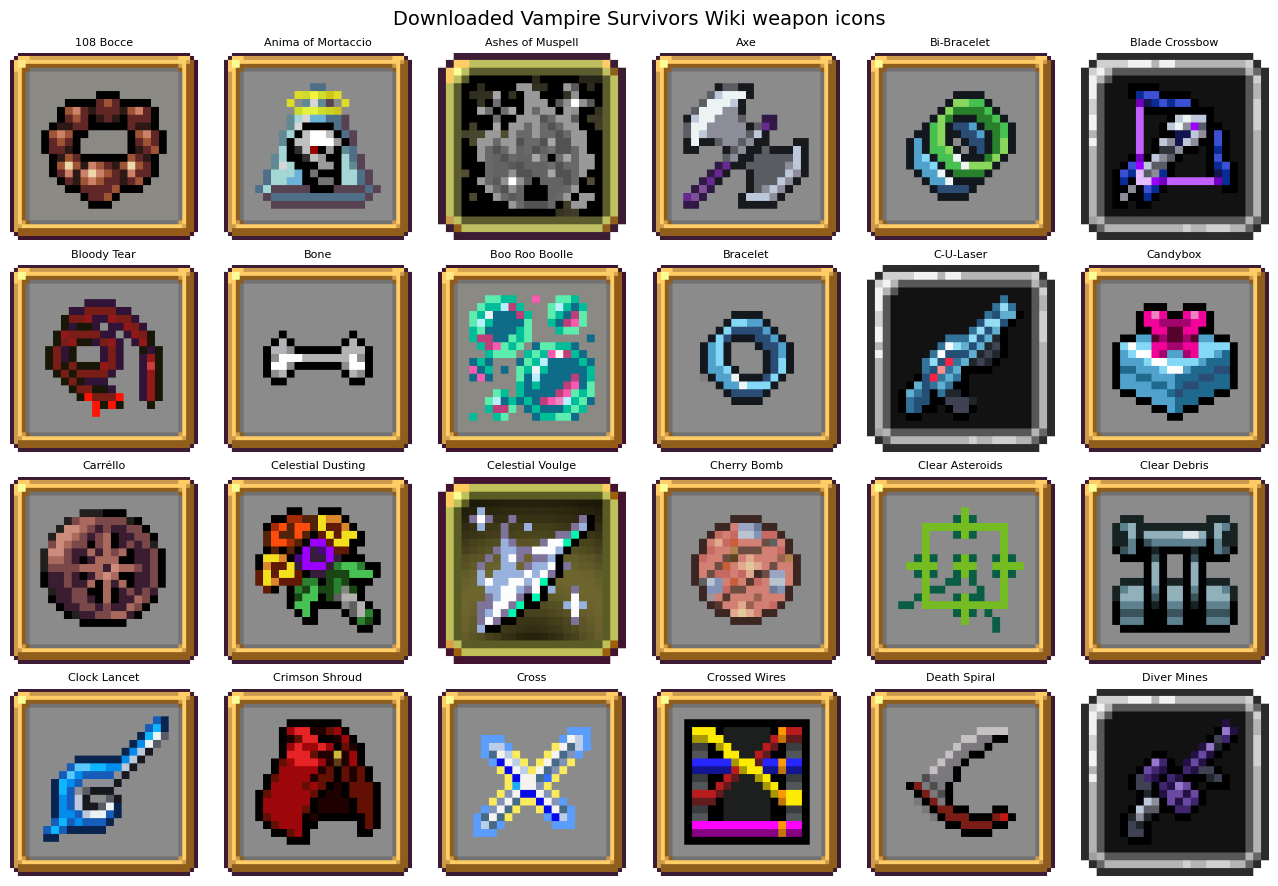

In [5]:
# A small visual audit of the local catalogue. Increase PREVIEW_COUNT to see more.
PREVIEW_COUNT = 24
preview = manifest.head(PREVIEW_COUNT)
fig, axes = plt.subplots(4, 6, figsize=(13, 9))
for axis, row in zip(axes.flat, preview.itertuples(index=False)):
    icon = cv2.imread(str(ICON_DIR / row.filename), cv2.IMREAD_UNCHANGED)
    if icon.shape[-1] == 4:
        axis.imshow(cv2.cvtColor(icon, cv2.COLOR_BGRA2RGBA))
    else:
        axis.imshow(cv2.cvtColor(icon, cv2.COLOR_BGR2RGB))
    axis.set_title(row.weapon_name, fontsize=8)
    axis.axis("off")
plt.suptitle("Downloaded Vampire Survivors Wiki weapon icons", fontsize=14)
plt.tight_layout()
plt.show()

## How the Detector Works

For each sampled video time, the script:

1. detects large gold-framed level-up/status overlays and moves to the nearest clean gameplay frame;
2. finds the long gold experience-bar frame at the top of the screen;
3. uses that bar and the video height to scale the six first-row HUD cells automatically;
4. takes a median of nearby frames so moving enemies and effects fade while fixed HUD icons remain;
5. removes the gold collection border and gray background from each wiki reference;
6. compares masked pixel color/shape plus an HSV color histogram;
7. reports the best match, runner-up, score margin, and confidence; and
8. stabilizes the timeline, accepting a new identity only when it persists across samples.

The stabilized columns are the main result. Columns beginning with `raw_` preserve every original frame-level suggestion for auditing.

## Choose a Video and Inspect One Frame

Video 4 is the default example. The 300-second frame is useful because it visibly contains five weapons. Change these values to inspect another recording or time.

In [6]:
VIDEO_PATH = VIDEO_DIR / "video4_Imelda_100.mp4"
GAMEPLAY_START_SECOND = 10.0
INSPECT_SECOND = 300.0

# Other project videos:
# VIDEO_PATH = VIDEO_DIR / "video5_Imelda_1000_part1.mp4"
# VIDEO_PATH = VIDEO_DIR / "Video1_Imelda.mp4"

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps
cap.release()

pd.DataFrame([{
    "video": VIDEO_PATH.name, "fps": fps, "frames": frame_count,
    "duration_seconds": duration, "width": width, "height": height,
}])

,video,fps,frames,duration_seconds,width,height
0,video4_Imelda_100.mp4,30.0,35886,1196.2,2560,1440


In [7]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
frame, frame_second_used, screen_state = detector.read_nearest_gameplay_frame(
    cap, INSPECT_SECOND, duration=duration
)
frame = detector.read_temporal_median(
    cap, frame_second_used, offsets=(-0.24, 0.0, 0.24)
)
cap.release()

detections, layout, references = detector.analyze_weapon_frame(
    frame, ICON_DIR, manifest, config=config
)
print("Requested second:", INSPECT_SECOND)
print("Frame second used:", frame_second_used)
print("Screen state:", screen_state)
print("Detected HUD layout:", layout)
display(detections[[
    "slot", "occupied", "weapon", "runner_up", "match_score",
    "score_margin", "confidence", "needs_review"
]])

Requested second: 300.0
Frame second used: 300.0
Screen state: gameplay
Detected HUD layout: HUDLayout(x=135, y=50, slot_size=56, step_x=59, slots=6, bar_x=130, bar_y=2, bar_width=2302, bar_height=45)


,slot,occupied,weapon,runner_up,match_score,score_margin,confidence,needs_review
0,1,True,Magic Wand,Luminaire,0.856747,0.339377,high,False
1,2,True,King Bible,Death Spiral,0.679153,0.111119,high,False
2,3,True,Peachone,Runetracer,0.759710,0.181107,high,False
3,4,True,Lightning Ring,Lucky Swipe,0.607900,0.141979,high,False
4,5,True,Pentagram,Song of Mana,0.498225,0.027650,medium,False
5,6,False,,,NaN,NaN,empty,False


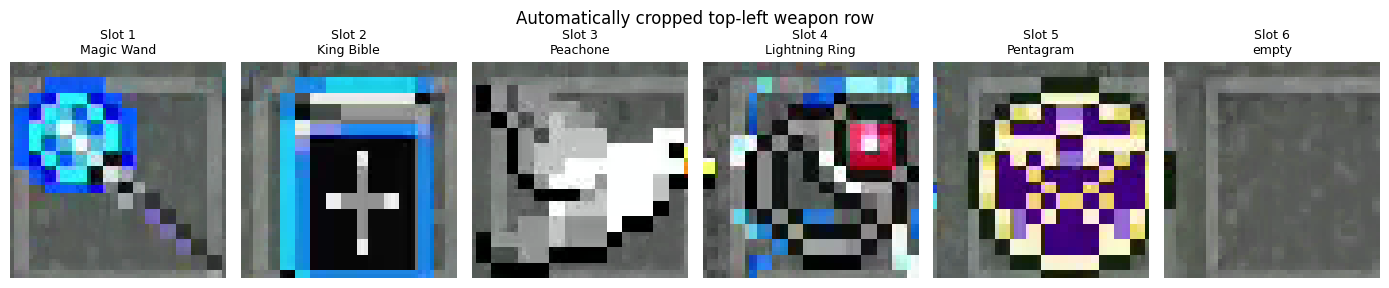

In [8]:
slot_crops = detector.crop_weapon_slots(frame, layout)
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for index, (axis, crop) in enumerate(zip(axes, slot_crops), start=1):
    axis.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    row = detections.iloc[index - 1]
    title = row.weapon if row.occupied else "empty"
    axis.set_title(f"Slot {index}\n{title}", fontsize=9)
    axis.axis("off")
plt.suptitle("Automatically cropped top-left weapon row")
plt.tight_layout()
plt.show()

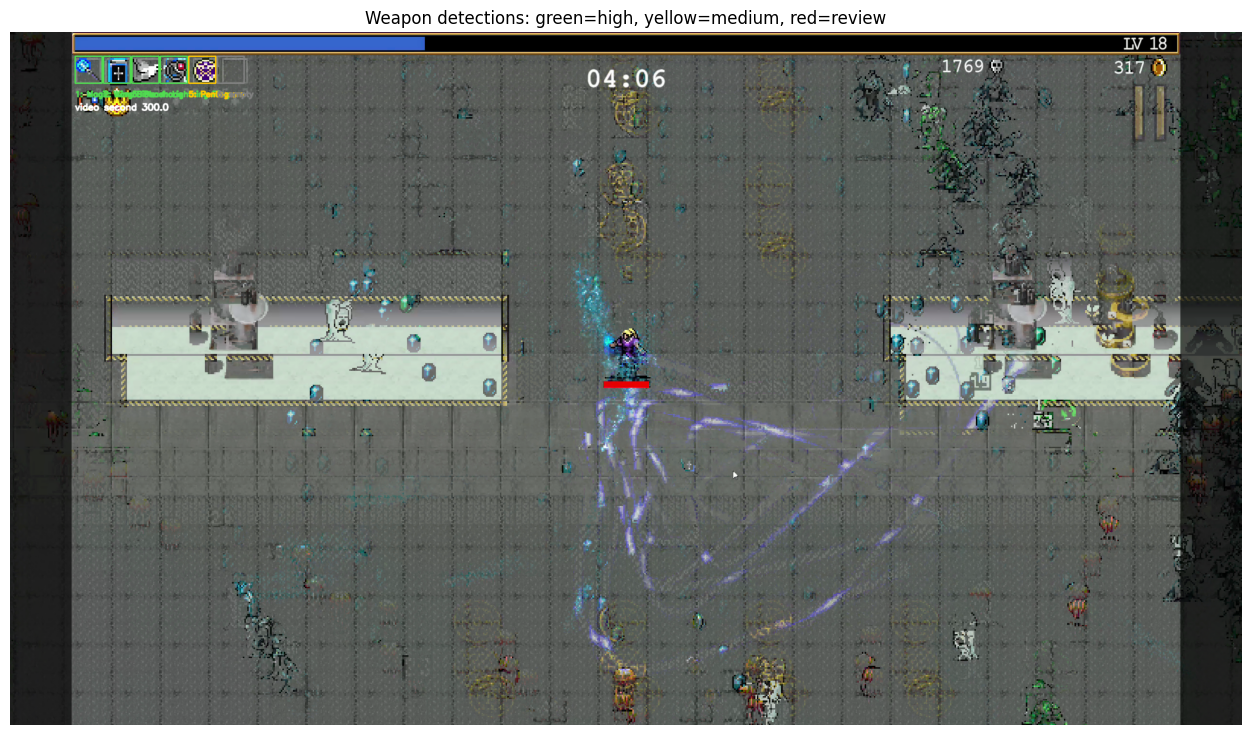

In [9]:
annotated = detector.annotate_weapon_frame(
    frame, detections, layout, frame_second_used
)
plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Weapon detections: green=high, yellow=medium, red=review")
plt.axis("off")
plt.show()

## Reading Confidence Correctly

- **High:** strong score and a clear gap over the runner-up.
- **Medium:** usable automated match, but a smaller visual margin.
- **Low / needs review:** the best suggestion is retained, but a human should check it.
- **UNKNOWN:** no reference reached the minimum absolute score.

Old recordings may use an earlier icon revision than the current wiki. Stabilization helps, but low-confidence evolution icons should still be visually checked.

## Run a Short End-to-End Test

This records seconds 10 through 60 at 10-second intervals. Change `sample_interval` to `5.0` for the intended research output. The quick test demonstrates menu avoidance, persistent-slot stabilization, CSV creation, and debug frames.

In [ ]:
SHORT_TEST_DIR = RESULTS_DIR / detector.clean_video_label(VIDEO_PATH) / "notebook_60s_test"

timeline_path, events_path, debug_dir = detector.record_video_weapons(
    video_path=VIDEO_PATH,
    output_dir=SHORT_TEST_DIR,
    icon_dir=ICON_DIR,
    manifest_path=MANIFEST_PATH,
    start_second=GAMEPLAY_START_SECOND,
    end_second=60.0,
    sample_interval=10.0,
    debug_every_seconds=20.0,
)
print("Timeline CSV:", timeline_path)
print("Event CSV:", events_path)
print("Debug folder:", debug_dir)

In [11]:
timeline = pd.read_csv(timeline_path)
events = pd.read_csv(events_path)

main_columns = [
    "time_stamp", "frame_second_used", "screen_state",
    "weapon_count", "review_count",
] + [f"weapon_{slot}" for slot in range(1, 7)]
display(timeline[main_columns])
display(events)

,time_stamp,frame_second_used,screen_state,weapon_count,review_count,weapon_1,weapon_2,weapon_3,weapon_4,weapon_5,weapon_6
0,00:10,12.0,gameplay_near_overlay,2,0,Magic Wand,King Bible,NaN,NaN,NaN,NaN
1,00:20,20.0,gameplay,2,0,Magic Wand,King Bible,NaN,NaN,NaN,NaN
2,00:30,30.0,gameplay,3,0,Magic Wand,King Bible,Peachone,NaN,NaN,NaN
3,00:40,40.0,gameplay,3,0,Magic Wand,King Bible,Peachone,NaN,NaN,NaN
4,00:50,50.0,gameplay,3,0,Magic Wand,King Bible,Peachone,NaN,NaN,NaN
5,01:00,60.0,gameplay,3,0,Magic Wand,King Bible,Peachone,NaN,NaN,NaN


,video,video_second,time_stamp,slot,event,previous_weapon,weapon,suggested_weapon,confidence,match_score,score_margin,needs_review
0,video4_Imelda_100.mp4,10.0,00:10,1,initial,NaN,Magic Wand,Magic Wand,high,0.771870,0.285902,False
1,video4_Imelda_100.mp4,10.0,00:10,2,initial,NaN,King Bible,King Bible,high,0.699418,0.172447,False
2,video4_Imelda_100.mp4,30.0,00:30,3,acquired,NaN,Peachone,Peachone,high,0.872340,0.186255,False


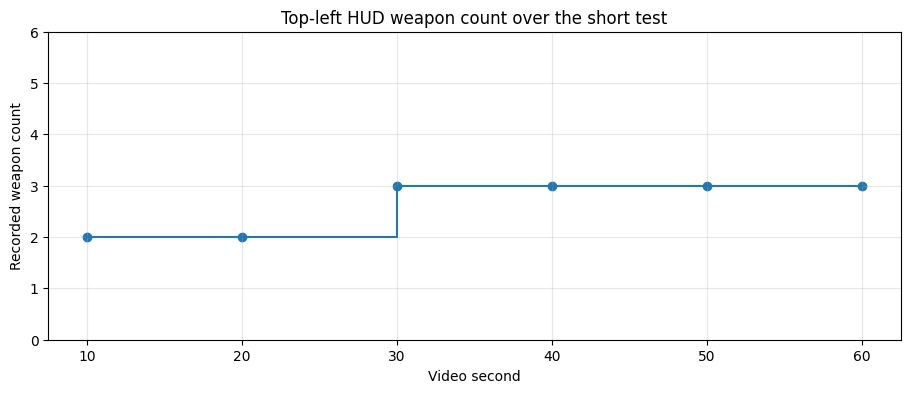

In [12]:
plt.figure(figsize=(11, 4))
plt.step(timeline["video_second"], timeline["weapon_count"], where="post")
plt.scatter(timeline["video_second"], timeline["weapon_count"])
plt.yticks(range(0, 7))
plt.xlabel("Video second")
plt.ylabel("Recorded weapon count")
plt.title("Top-left HUD weapon count over the short test")
plt.grid(True, alpha=0.3)
plt.show()

## Optional: Record the Full Video

This is off by default. A 5-second interval matches the surrounding MNL coding workflow and gives the persistence filter enough neighboring samples. The final CSV keeps both stabilized and `raw_` columns.

In [13]:
RUN_FULL_VIDEO = False
SAMPLE_INTERVAL_SECONDS = 5.0

if RUN_FULL_VIDEO:
    full_output_dir = RESULTS_DIR / detector.clean_video_label(VIDEO_PATH)
    full_timeline, full_events, full_debug = detector.record_video_weapons(
        video_path=VIDEO_PATH,
        output_dir=full_output_dir,
        icon_dir=ICON_DIR,
        manifest_path=MANIFEST_PATH,
        start_second=GAMEPLAY_START_SECOND,
        end_second=None,
        sample_interval=SAMPLE_INTERVAL_SECONDS,
        debug_every_seconds=30.0,
    )
    print(full_timeline)
    print(full_events)
    print(full_debug)
else:
    print("Full run skipped. Set RUN_FULL_VIDEO = True to create it.")

Full run skipped. Set RUN_FULL_VIDEO = True to create it.


## Manual Calibration Fallback

Automatic scaling was validated on the project's 1920×1080, 2560×1440, and 2880×1800 recordings. If another layout fails, inspect a frame and pass a manual override:

```python
manual = detector.HUDLayout(x=135, y=50, slot_size=57, step_x=59)
detector.record_video_weapons(..., manual_layout=manual)
```

The four values are the first weapon cell's left coordinate, top coordinate, square size, and horizontal distance between cells.

## Quality-Control Checklist

Before using a full timeline in analysis:

1. inspect debug frames at early, middle, and late times;
2. filter rows where `review_count > 0`;
3. compare stabilized `weapon_*` values with `raw_weapon_*` suggestions;
4. inspect every `changed_or_evolved` event;
5. confirm the first detected row starts after gameplay begins; and
6. keep the manifest with the CSV so the exact reference catalogue remains reproducible.

The method is designed to reduce manual coding, not to conceal uncertainty.

## Terminal Equivalent

From the UCSB project root, the reusable script can be run without Jupyter:

```bash
python3 'MNL/03_weapons/scripts/weapon_screen_recorder.py' \
  --video 'MNL/videos/video4_Imelda_100.mp4' \
  --output-dir 'MNL/03_weapons/results/video4_imelda_100' \
  --icon-dir 'MNL/03_weapons/templates/wiki_icons' \
  --manifest 'MNL/03_weapons/data/wiki_weapon_manifest.csv' \
  --start 10 --interval 5 --debug-every 30
```